#  MuJoCo Bootcamp : Hybrid Systems

---- 

- conda env : [ai_robotics](../../../README.md#setup-a-conda-environment)

---

### Reference : 
- https://pab47.github.io/mujoco.html
- https://youtu.be/p5_nQcsg2jM

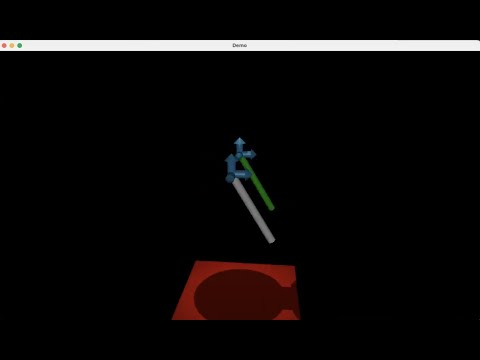

In [1]:
from IPython.display import YouTubeVideo

YouTubeVideo('p5_nQcsg2jM')

## Run python code

In [2]:
!python hybrid_pendulum.py 

## Jupyter code

### Load XML file and build model and data

In [1]:
import mujoco as mj
import numpy as np
import mediapy as media
from numpy.linalg import inv
from scipy.linalg import solve_continuous_are
import os

# Create an XML file string for a simple ball on a plane
xml_path = "./pendulum.xml" 

# MuJoCo data structures
model = mj.MjModel.from_xml_path(xml_path)
data = mj.MjData(model)

### Setup the controller

In [2]:
FSM_SWING = 0
FSM_FREE = 1

fsm = FSM_SWING

def controller(model, data):
    """
    This function implements a controller that
    mimics the forces of a fixed joint before release
    """
    global fsm
    

    # Get the number of equality constraints and degrees of freedom
    neq = model.neq
    nv = model.nv

    # Reshape the flattened efc_J into a 2D matrix
    # The shape should be (number of constraints, number of degrees of freedom)
    efc_J_2d = data.efc_J.reshape(-1, nv)
    if len(data.efc_J) % 3 != 0:
        print(data.efc_J.shape)

    # Now you can slice the 2D array correctly.
    # The `connect` constraint is the only one, so it corresponds to the first 3 rows.
    # The first body's joints (x, z, pin) correspond to the first 3 columns.
    # You can choose to get the Jacobian relative to the first 3 joints
    # by taking all rows and the first 3 columns, or the full 3x6 matrix.
    # This example takes the full 3x6 Jacobian.
    J = efc_J_2d[:3, :3]

    # Get constraint Jacobian
    # print(data.efc_J)
    # J = data.efc_J[:3, :3]

    # Get constraint force
    F0 = data.efc_force[:3][:, np.newaxis]

    # Get constrained joint torque
    JT_F = J.T @ F0

    # Release condition check
    if fsm == FSM_SWING and data.qpos[5] > 1.0:
        fsm = FSM_FREE

    if fsm == FSM_SWING:
        data.qfrc_applied[2] = -1 * (data.qvel[2] - 5.0)
        data.qfrc_applied[3] = JT_F[0, 0]
        data.qfrc_applied[4] = JT_F[1, 0]
        data.qfrc_applied[5] = JT_F[2, 0] + data.qfrc_applied[2]
    elif fsm == FSM_FREE:
        data.qfrc_applied[3] = 0.0
        data.qfrc_applied[4] = 0.0
        data.qfrc_applied[5] = 0.0

mj.set_mjcb_control(controller)

### Setup the configuration of render

In [3]:
# Offscreen rendering setup
width, height = 200, 200
renderer = mj.Renderer(model, width, height)

# Set camera configuration
cam = mj.MjvCamera()                        # Abstract camera
opt = mj.MjvOption()                        # visualization options
mj.mjv_defaultCamera(cam)
mj.mjv_defaultOption(opt)
# Set camera configuration
cam.azimuth = 89.608063
cam.elevation = -11.588379
cam.distance = 5.0
cam.lookat = np.array([0.0, 0.0, 1.5])

### Initialization 

In [4]:
# Set initial configuration
data.qpos[2] = -np.pi/2
data.qpos[5] = -np.pi/2



### Simulation

In [5]:
# Store frames for visualization
frames = []
framerate = 60
simend = 5


while data.time < simend:
    simstart = data.time
    while (data.time - simstart < 1.0/60.0):
        mj.mj_step(model, data)
    
    # Render the scene from the specified camera
    renderer.update_scene(data, camera=cam)
    
    # Get the rendered RGB image and store it
    rgb_image = renderer.render()
    frames.append(rgb_image)

media.show_video(frames, fps=framerate)




This browser does not support the video tag.
